In [152]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [153]:
data = pd.read_csv("../data/clean/cleaned_data.csv")

In [154]:
data

,city,zip_code,latitude,longitude,gender,senior_citizen,partner,dependents,tenure_months,phone_service,...,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_value,churn_score,cltv,churn_reason
0,Los Angeles,90003,33.964131,-118.272783,Male,No,No,No,2,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,86,3239,Competitor made better offer
1,Los Angeles,90005,34.059281,-118.307420,Female,No,No,Yes,2,Yes,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,67,2701,Moved
2,Los Angeles,90006,34.048013,-118.293953,Female,No,No,Yes,8,Yes,...,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,86,5372,Moved
3,Los Angeles,90010,34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,...,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,84,5003,Moved
4,Los Angeles,90015,34.039224,-118.266293,Male,No,No,Yes,49,Yes,...,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Landers,92285,34.341737,-116.539416,Female,No,No,No,72,Yes,...,No,Two year,Yes,Bank transfer (automatic),21.15,1419.40,0,45,5306,NaN
7039,Adelanto,92301,34.667815,-117.536183,Male,No,Yes,Yes,24,Yes,...,Yes,One year,Yes,Mailed check,84.80,1990.50,0,59,2140,NaN
7040,Amboy,92304,34.559882,-115.637164,Female,No,Yes,Yes,72,Yes,...,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0,71,5560,NaN
7041,Angelus Oaks,92305,34.167800,-116.864330,Female,No,Yes,Yes,11,No,...,No,Month-to-month,Yes,Electronic check,29.60,346.45,0,59,2793,NaN


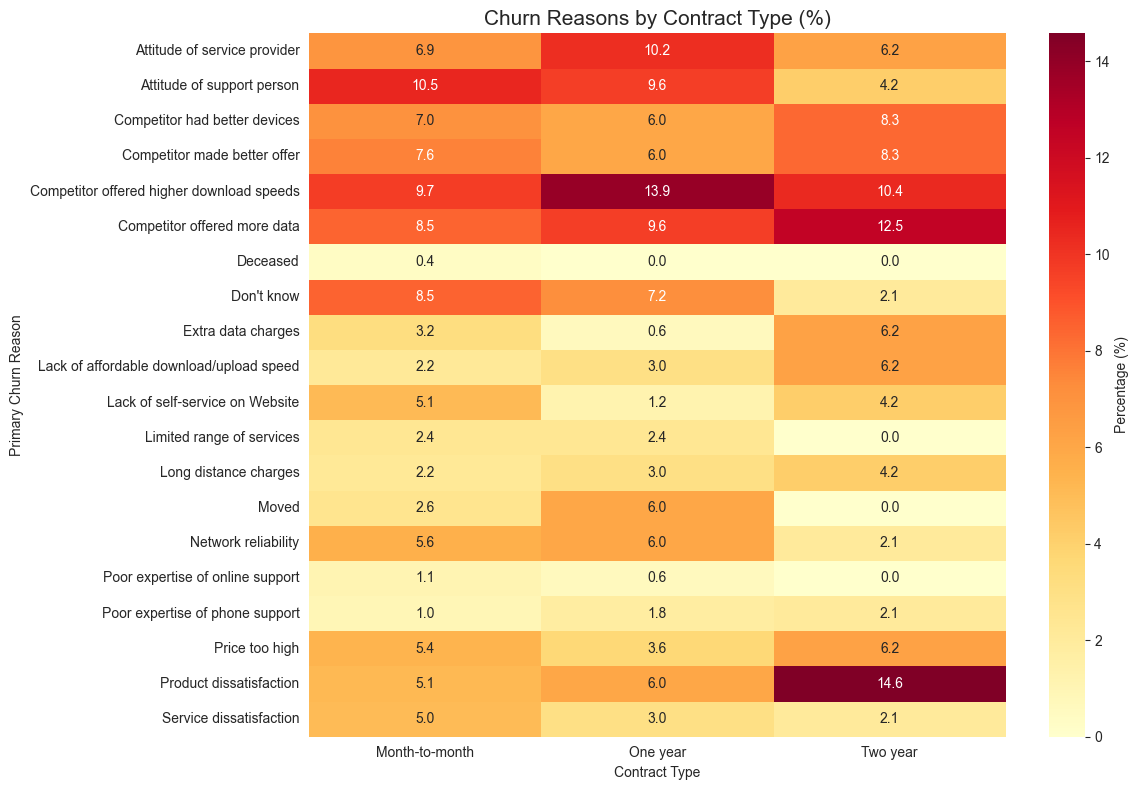

In [155]:
churned = data[data["churn_value"] == 1]

reason_matrix = pd.crosstab(churned["churn_reason"], churned["contract"], normalize="columns")*100

plt.figure(figsize=(12, 8))
sns.heatmap(reason_matrix, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={"label": "Percentage (%)"})
plt.title("Churn Reasons by Contract Type (%)", fontsize=15)
plt.xlabel("Contract Type")
plt.ylabel("Primary Churn Reason")
plt.tight_layout()
plt.show()

In [156]:
corr_data = data.copy()

data_dummies = pd.get_dummies(corr_data[["churn_value","phone_service","multiple_lines","internet_service","online_security",
                                 "online_backup","device_protection","tech_support","streaming_tv", "streaming_movies"]])
data_dummies.head()

,churn_value,phone_service_No,phone_service_Yes,multiple_lines_No,multiple_lines_Yes,internet_service_DSL,internet_service_Fiber optic,internet_service_No,online_security_No,online_security_Yes,online_backup_No,online_backup_Yes,device_protection_No,device_protection_Yes,tech_support_No,tech_support_Yes,streaming_tv_No,streaming_tv_Yes,streaming_movies_No,streaming_movies_Yes
0,1,False,True,True,False,True,False,False,False,True,False,True,True,False,True,False,True,False,True,False
1,1,False,True,True,False,False,True,False,True,False,True,False,True,False,True,False,True,False,True,False
2,1,False,True,False,True,False,True,False,True,False,True,False,False,True,True,False,False,True,False,True
3,1,False,True,False,True,False,True,False,True,False,True,False,False,True,False,True,False,True,False,True
4,1,False,True,False,True,False,True,False,True,False,False,True,False,True,True,False,False,True,False,True


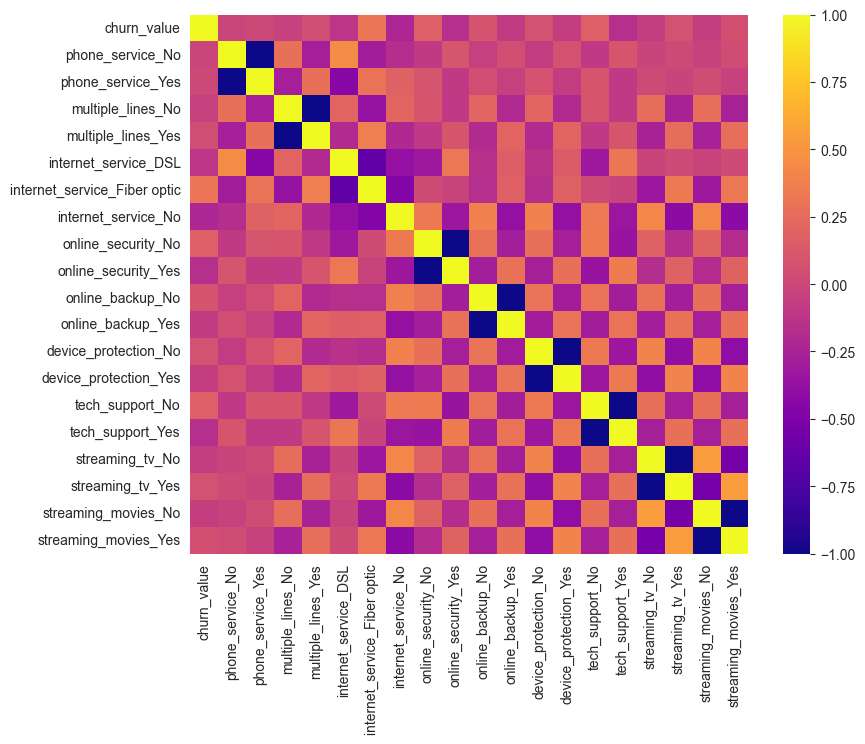

In [157]:
plt.figure(figsize=(9, 7))
sns.heatmap(data_dummies.corr(), annot=False, cmap='plasma')

plt.show()

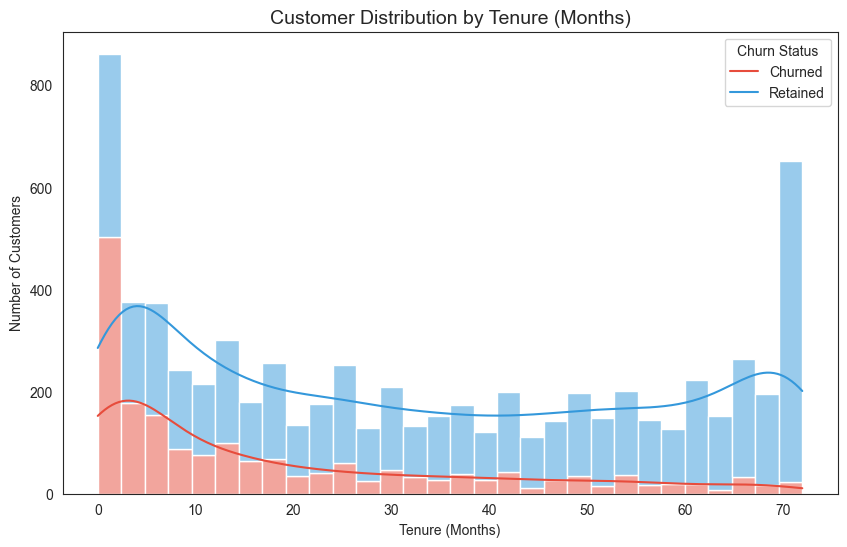

In [158]:
plt.figure(figsize=(10, 6))

sns.histplot(data=data, x="tenure_months", hue="churn_value",
             multiple="stack", palette={0: '#3498db', 1: '#e74c3c'},
             bins=30, kde=True)

plt.title("Customer Distribution by Tenure (Months)", fontsize=14)
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.legend(title="Churn Status", labels=["Churned", "Retained"])
plt.show()

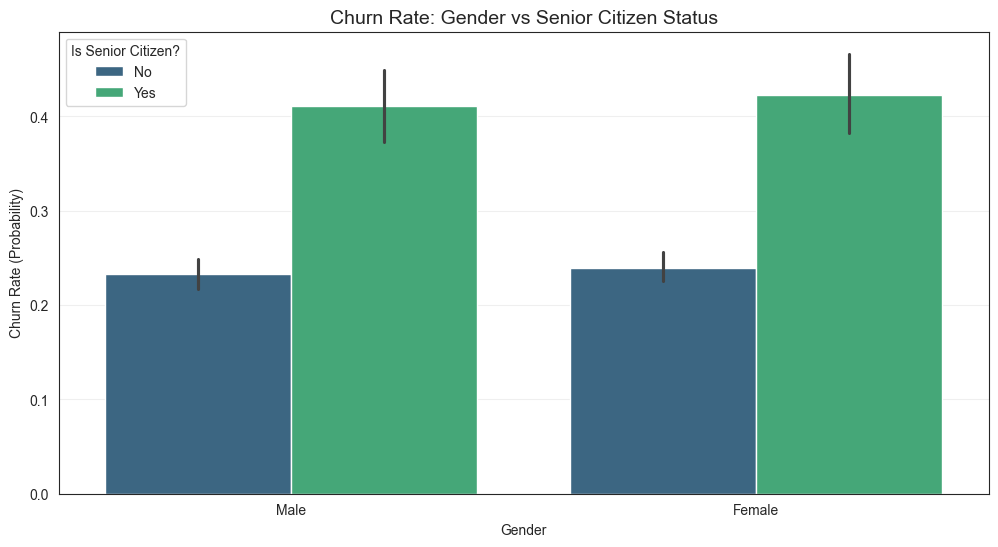

In [159]:
plt.figure(figsize=(12, 6))

sns.barplot(data=data, x='gender', y='churn_value', hue='senior_citizen', palette='viridis')

plt.title('Churn Rate: Gender vs Senior Citizen Status', fontsize=14)
plt.ylabel('Churn Rate (Probability)')
plt.xlabel('Gender')
plt.legend(title='Is Senior Citizen?')
plt.grid(axis='y', alpha=0.3)
plt.show()

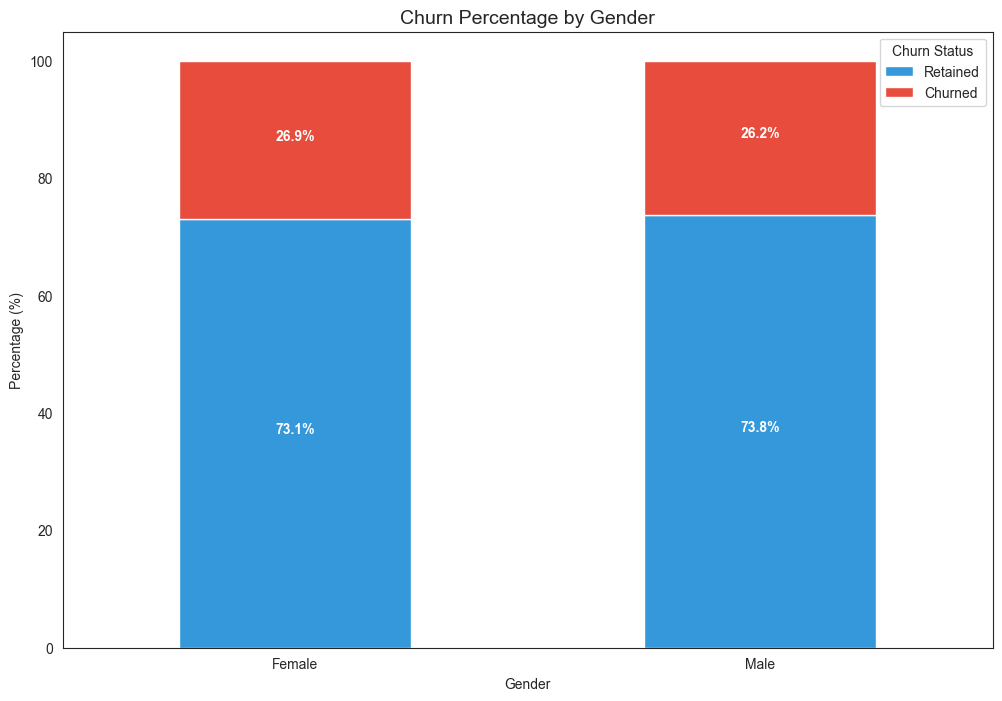

In [160]:
gender_churn = pd.crosstab(data["gender"], data["churn_value"], normalize="index") * 100

ax = gender_churn.plot(kind="bar", stacked=True, figsize=(12, 8), color=["#3498db", "#e74c3c"])

plt.title("Churn Percentage by Gender", fontsize=14)
plt.xlabel("Gender")
plt.ylabel("Percentage (%)")
plt.legend(title="Churn Status", labels=["Retained", "Churned"], loc="upper right")
plt.xticks(rotation=0)

# Add percentage text on the bars
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text(x+width/2, y+height/2, f'{height:.1f}%', transform=ax.transData, ha="center", color="white", fontweight="bold")

plt.show()

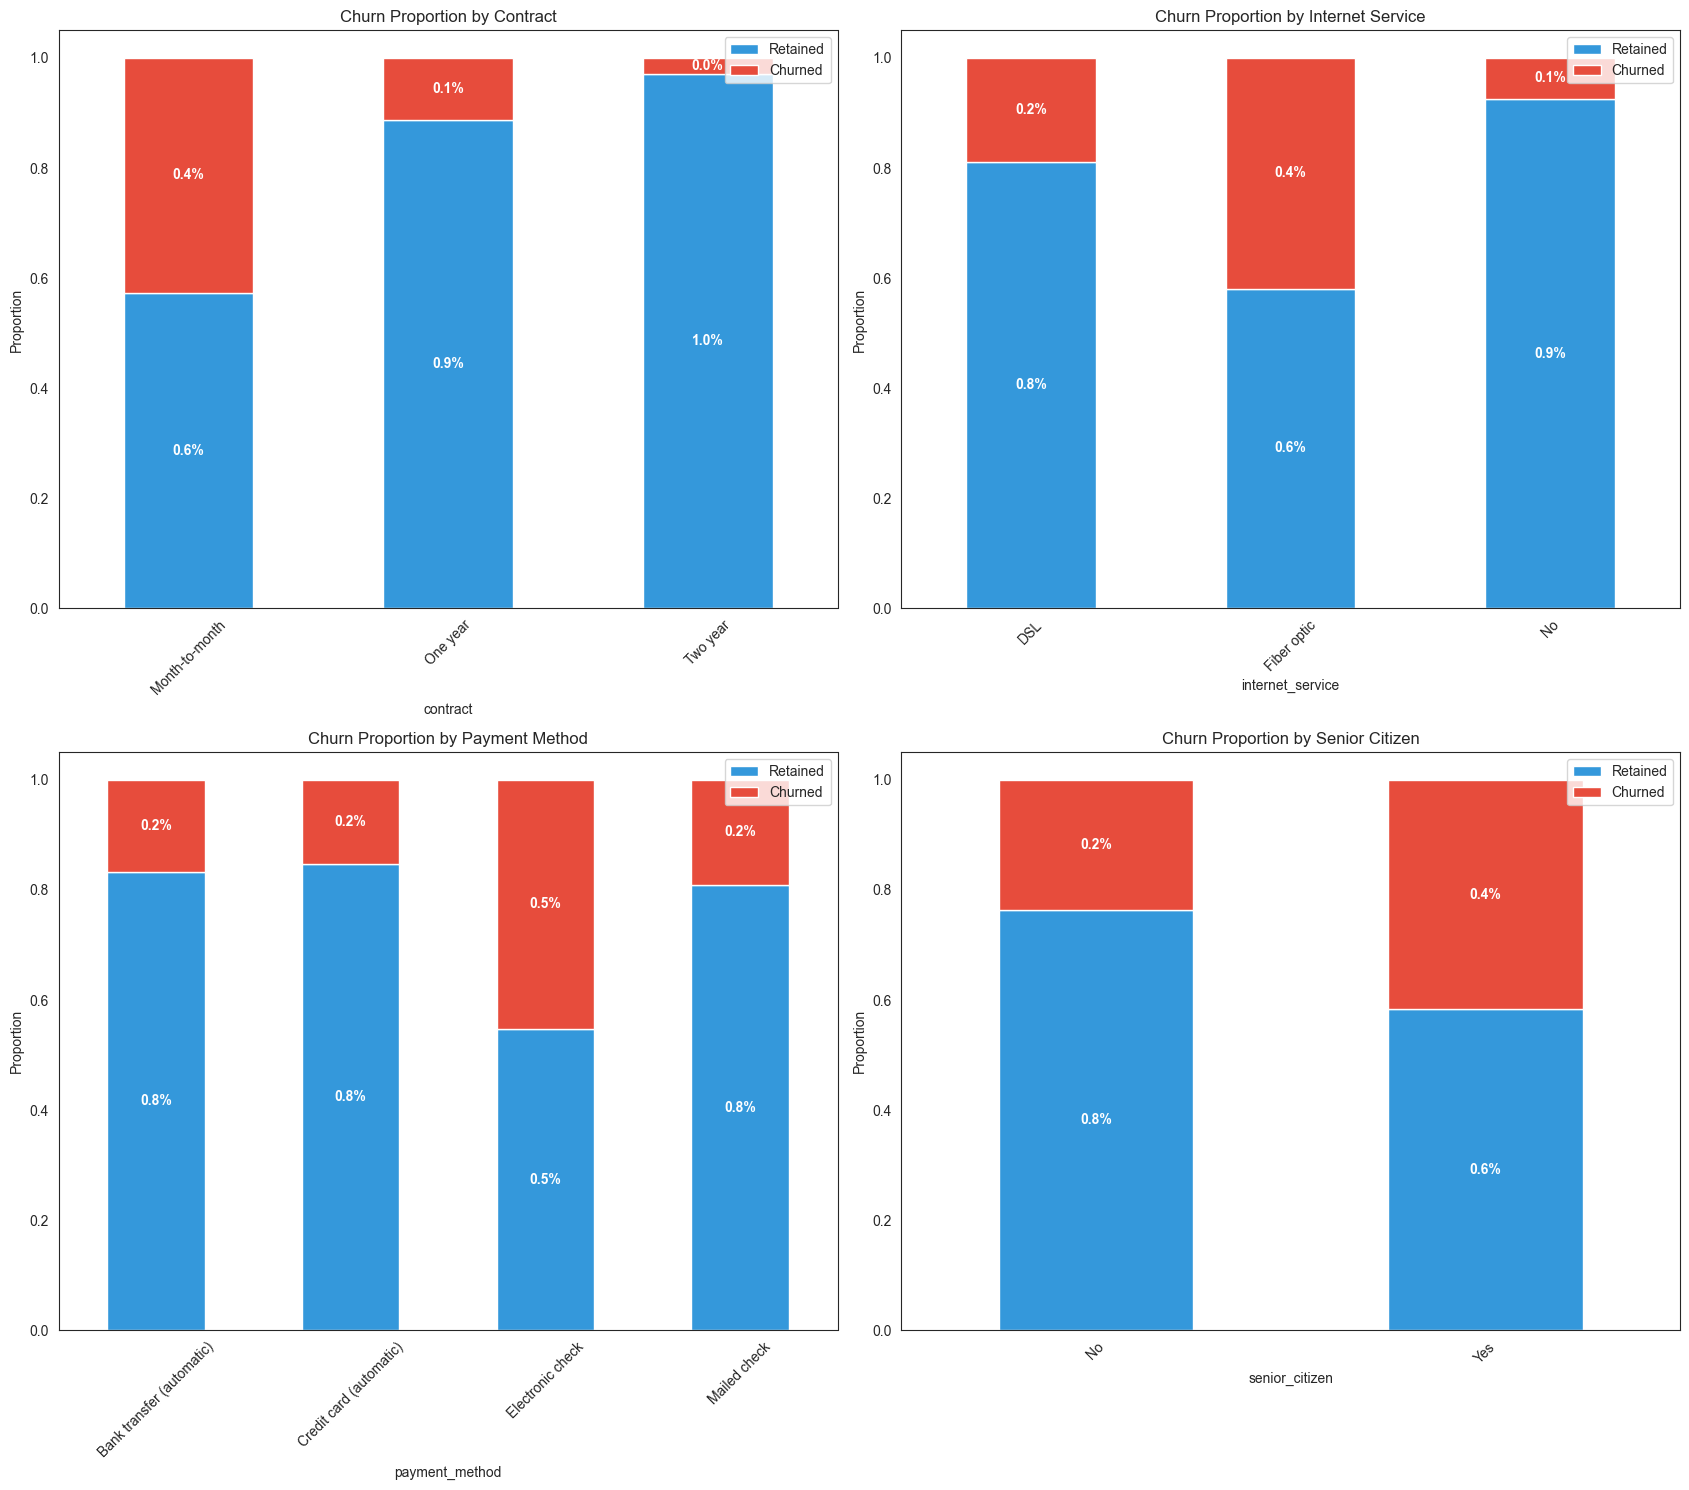

In [161]:
features = ["contract", "internet_service", "payment_method", "senior_citizen"]

fig, axes = plt.subplots(nrows = 2, ncols=2, figsize = (17, 15))
axes = axes.flatten()

for i, col in enumerate(features):
    proportions = pd.crosstab(data[col], data["churn_value"], normalize="index")
    proportions.plot(kind="bar", ax=axes[i], stacked = True, color=["#3498db", "#e74c3c"])

    for p in axes[i].patches:
        width, height = p.get_width(), p.get_height()
        x, y = p.get_xy()

        if height > 0:
            axes[i].text(x + width/2, y + height/2, f'{height:.1f}%', ha="center", va="center", color="white", fontweight="bold")

    axes[i].set_title(f'Churn Proportion by {col.replace("_", " ").title()}')
    axes[i].set_ylabel("Proportion")
    axes[i].legend(["Retained", "Churned"], loc="upper right")
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


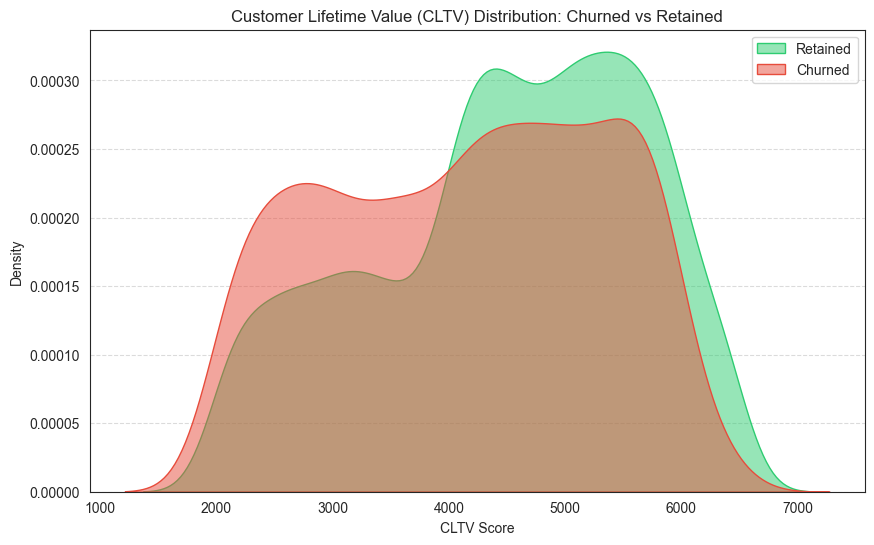

In [162]:
plt.figure(figsize=(10, 6))

sns.kdeplot(data=data[data["churn_value"] == 0], x="cltv", fill=True, label="Retained", color='#2ecc71', alpha=0.5)
sns.kdeplot(data=data[data["churn_value"] == 1], x="cltv", fill=True, label="Churned", color="#e74c3c", alpha=0.5)

plt.title("Customer Lifetime Value (CLTV) Distribution: Churned vs Retained")
plt.xlabel("CLTV Score")
plt.ylabel("Density")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

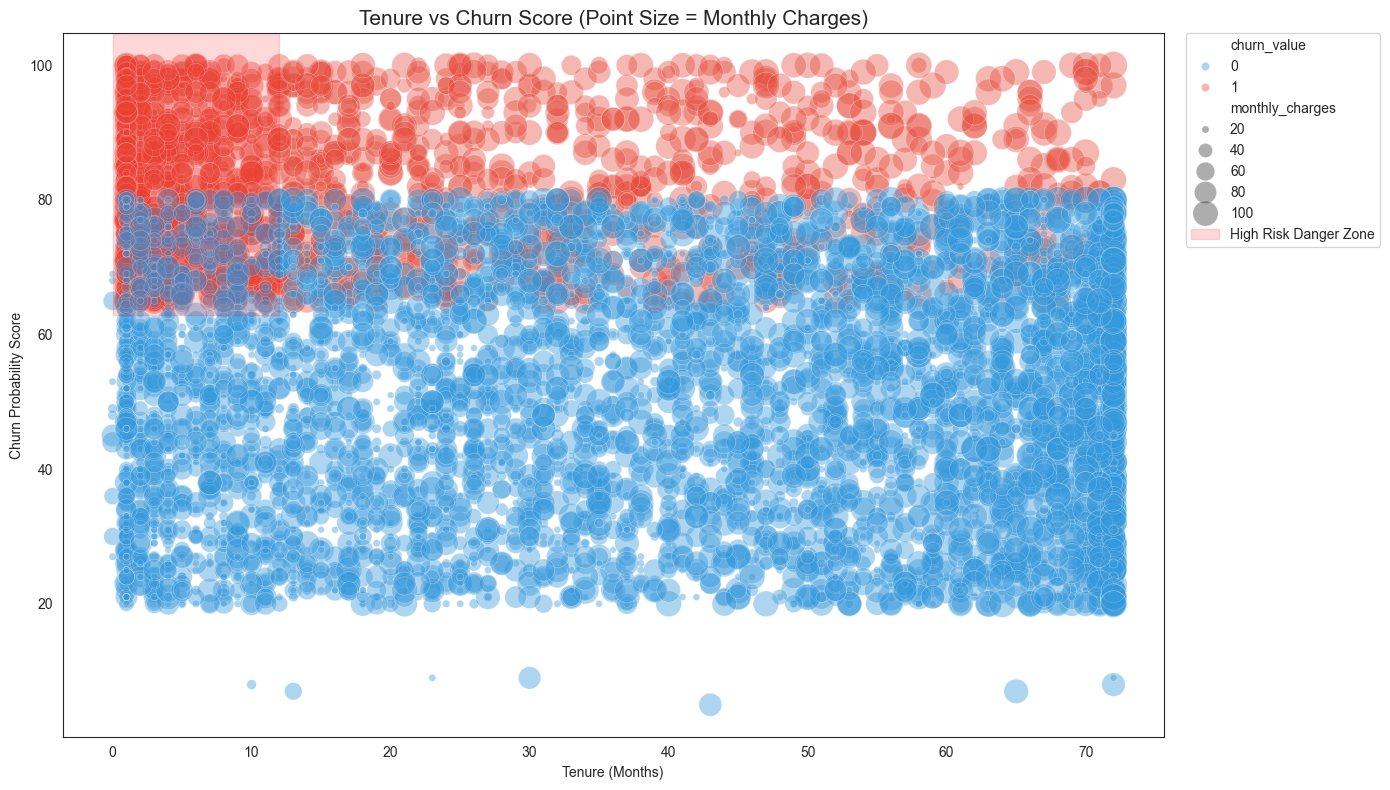

In [163]:
plt.figure(figsize=(14, 8))

# Scatter plot using tenure, churn score, and monthly charges
scatter = sns.scatterplot(data=data, x="tenure_months", y="churn_score",
                          hue="churn_value", size="monthly_charges",
                          sizes=(20, 400), alpha=0.4,
                          palette={0: "#3498db", 1: "#e74c3c"})

# Defining the "Danger Zone" (first 12 months with high churn score)
plt.axvspan(0, 12, ymin=0.6, ymax=1, color="red", alpha=0.15, label="High Risk Danger Zone")

plt.title("Tenure vs Churn Score (Point Size = Monthly Charges)", fontsize=15)
plt.xlabel("Tenure (Months)")
plt.ylabel("Churn Probability Score")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

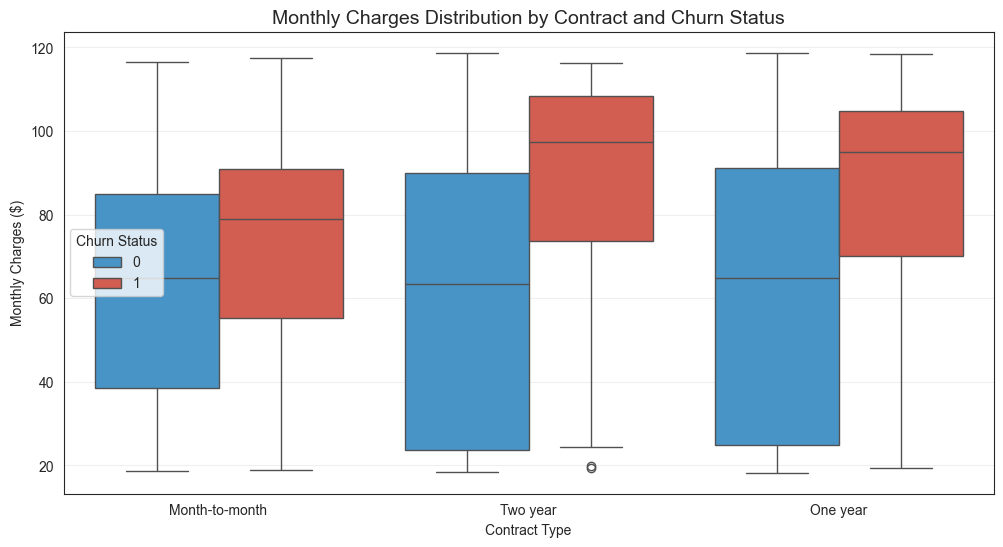

In [164]:
plt.figure(figsize=(12,6))

sns.boxplot(x="contract", y="monthly_charges", hue="churn_value", data=data, palette={0: '#3498db', 1:'#e74c3c'})

plt.title("Monthly Charges Distribution by Contract and Churn Status", fontsize=14)
plt.xlabel("Contract Type")
plt.ylabel("Monthly Charges ($)")
plt.legend(title="Churn Status")
plt.grid(axis="y", alpha=0.3)
plt.show()

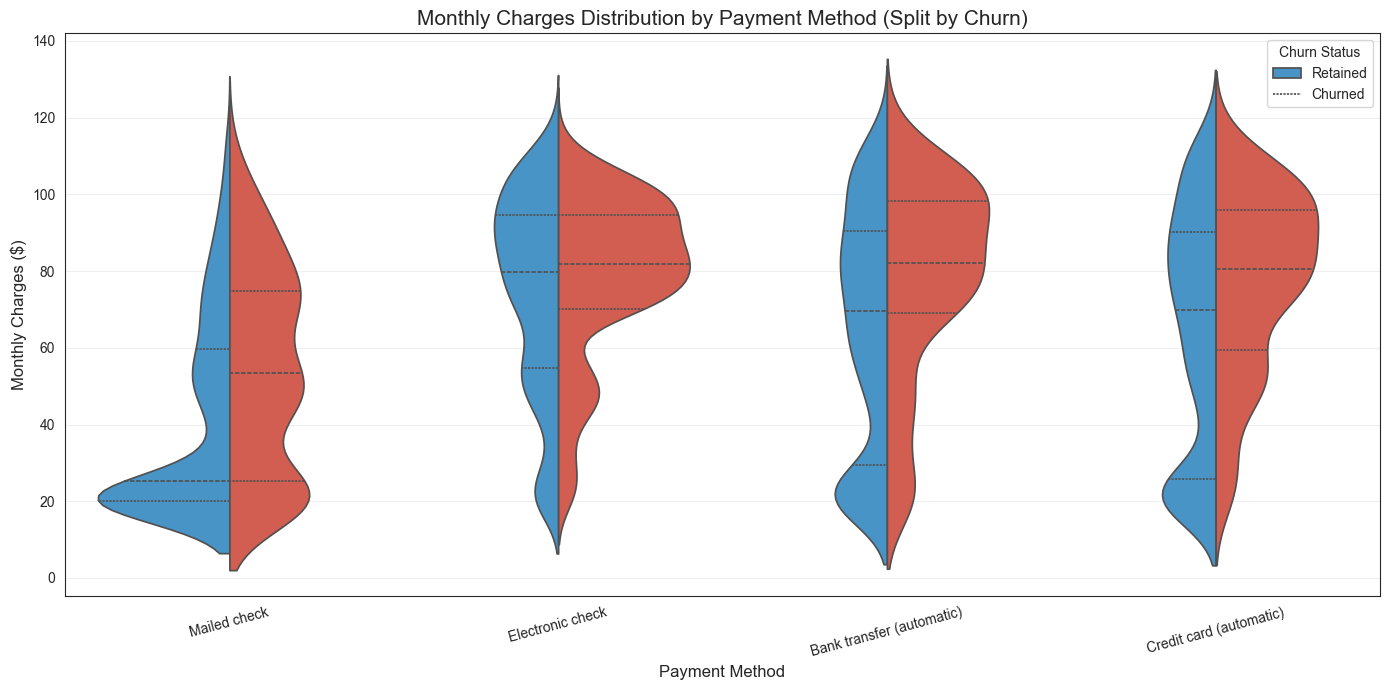

In [165]:
plt.figure(figsize=(14, 7))

# Split=True is the magic parameter here. It puts Retained on the left and Churned on the right of each violin.
sns.violinplot(
    data=data,
    x="payment_method",
    y="monthly_charges",
    hue="churn_value",
    split=True,
    inner="quart", # Shows the quartiles inside the violin
    palette={0: "#3498db", 1: "#e74c3c"}
)

plt.title("Monthly Charges Distribution by Payment Method (Split by Churn)", fontsize=15)
plt.xlabel("Payment Method", fontsize=12)
plt.ylabel("Monthly Charges ($)", fontsize=12)
plt.xticks(rotation=15)

plt.legend(title="Churn Status", labels=["Retained", "Churned"])
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [166]:
fig = px.histogram(data, x="total_charges", color="churn_value", marginal="box")
fig.show()